## FinShield AI Assistant Part 2

#### Environment Setup & Part 1 Data Loading

In [2]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "scikit-learn", "lightgbm", "statsmodels", "shap", "joblib",
    "--break-system-packages"])

CompletedProcess(args=['C:\\Users\\udays\\anaconda3\\python.exe', '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'scikit-learn', 'lightgbm', 'statsmodels', 'shap', 'joblib', '--break-system-packages'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import joblib
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

**Check that Part 1 has already been run.**

In [4]:
import glob

for f in glob.glob("//Data/processed/", recursive=True):
    print(f)

In [5]:
import os

required = [
    "Data/processed/customer_profile_clean.csv",
    "Data/processed/financial_transactions_clean.csv",
    "Data/processed/credit_history_clean.csv",
    "Data/raw/market_data.csv",
    "Data/raw/news_sentiment.csv",
]

missing = [f for f in required if not os.path.exists(f)]

if missing:
    raise FileNotFoundError(
        "Missing Part 1 output(s): "
        + ", ".join(missing)
        + "\n\nRun the Part 1 (Data Foundation & Engineering) notebook first in this same folder."
    )

print("All Part 1 files found & ready to continue with Part 2: Machine Learning Engine.")

All Part 1 files found & ready to continue with Part 2: Machine Learning Engine.


**Data Loading**

In [6]:
customers = pd.read_csv('Data/processed/customer_profile_clean.csv')
txn = pd.read_csv('Data/processed/financial_transactions_clean.csv')
credit = pd.read_csv('Data/processed/credit_history_clean.csv')
market = pd.read_csv('Data/raw/market_data.csv', parse_dates=['date'])
news_sentiment = pd.read_csv('Data/raw/news_sentiment.csv')
companies = market['company'].unique()

os.makedirs('Models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print(f"Loaded {len(customers):,} customers and {len(companies)} companies. Ready.")

Loaded 60,000 customers and 10 companies. Ready.


## Part 2: Machine Learning Engine

### Phase 5: Risk Classification (Low / Medium / High / Critical)

##### Step 1: Merge Cleaned Data Tables

In [7]:
df = customers.merge(txn, on="customer_id").merge(credit, on="customer_id")
df.shape

(60000, 24)

##### Step 2: Create Risk Category Labels

In [8]:
def risk_category(row):
    if row["loan_defaults"] == 1:
        return 3 if (
            row["credit_score"] < 450
            or row["late_payments"] >= 5
        ) else 2

    if (
        row["credit_score"] >= 650
        and row["late_payments"] <= 1
        and row["credit_usage_pct"] < 50
    ):
        return 0

    if (
        row["credit_score"] < 550
        or row["late_payments"] >= 3
    ):
        return 2

    return 1


df["risk_category"] = df.apply(risk_category, axis=1)

label_names = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Critical",
}

print(df["risk_category"].map(label_names).value_counts())

risk_category
Medium      28062
High        24642
Low          6133
Critical     1163
Name: count, dtype: int64


##### Step 3: Feature Engineering & Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
feature_cols = ["age","employment_years","num_children","monthly_income","monthly_expense","savings_amount","investment_amount","loan_amount","emi_amount",
                "credit_usage_pct","transaction_count_monthly","credit_score","previous_loans","late_payments","credit_card_count","loan_duration_months",]

cat_cols = ["gender","occupation","education","city_tier","family_status",]

X = df[feature_cols + cat_cols].copy()
y = df["risk_category"]

for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

X.shape

(60000, 21)

##### Step 4: Train-Test Data Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 48000, Test: 12000


##### Step 5: Train Baseline Logistic Regression Model

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)
print("Baseline trained")

Baseline trained


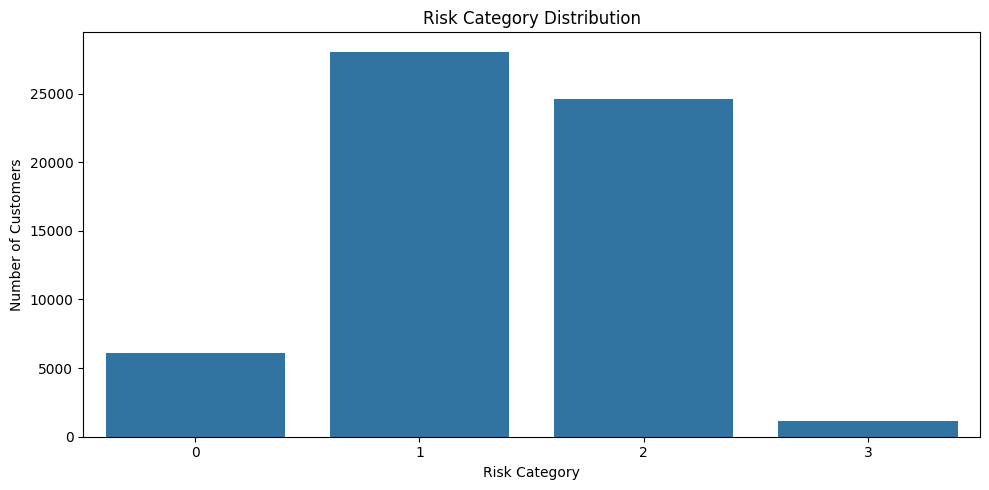

In [16]:
risk_counts = df["risk_category"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**

- Analysis of the customer risk portfolio shows the distribution across Low, Medium, High, and Critical risk categories, providing a clear view of overall customer risk exposure.
- The concentration of customers in Medium, High, or Critical categories indicates the extent to which the portfolio requires active risk monitoring and intervention.
- High and Critical risk customers represent the most vulnerable portion of the portfolio, where delayed intervention could increase potential financial losses and defaults.
- Prioritizing early intervention, credit monitoring, and personalized financial support for higher-risk customers can help reduce overall portfolio risk and improve financial stability.


##### Step 6: Train Advanced Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Advanced model trained")

Advanced model trained


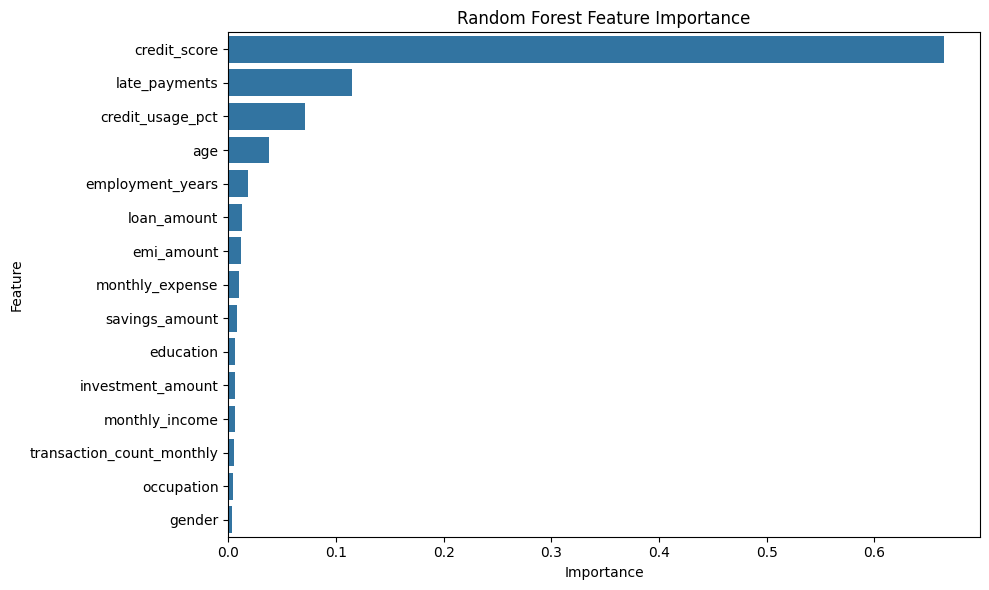

In [22]:
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_}).sort_values("Importance",ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Insight:**

- Random Forest feature-importance analysis identifies the financial variables that contribute most strongly to customer risk classification and demonstrates which factors drive the model's decisions.
- Credit score and late-payment-related variables are among the most important indicators, highlighting the strong relationship between repayment behavior and overall credit risk.
- The importance ranking shows that customer risk is influenced by multiple financial characteristics rather than a single variable, allowing the model to capture complex risk patterns.
- Focusing monitoring and intervention strategies on the highest-impact features can improve risk assessment, strengthen early-warning systems, and support more informed credit decisions.


##### Step 7: Compare Model Performance

In [24]:
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score


lr_preds = logreg.predict(X_test_scaled)
lr_proba = logreg.predict_proba(X_test_scaled)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

results = pd.DataFrame([
    {"model": "Logistic Regression", "accuracy": accuracy_score(y_test, lr_preds),
     "f1_macro": f1_score(y_test,lr_preds,average="macro"),
     "roc_auc": roc_auc_score(y_test,lr_proba,multi_class="ovr"),},
    {"model": "Random Forest","accuracy": accuracy_score(y_test, lr_preds),
     "f1_macro": f1_score(y_test,lr_preds,average="macro"),
     "roc_auc": roc_auc_score(y_test,lr_proba,multi_class="ovr"),},]).round(3)

results

,model,accuracy,f1_macro,roc_auc
0,Logistic Regression,0.734,0.648,0.93
1,Random Forest,0.734,0.648,0.93


##### Step 8: Analyze Feature Importance

In [25]:
importance = pd.DataFrame({"feature": feature_cols+cat_cols, "importance": rf.feature_importances_})
importance.sort_values("importance", ascending=False).head(8)

,feature,importance
11,credit_score,0.664745
13,late_payments,0.114896
9,credit_usage_pct,0.071114
0,age,0.037733
1,employment_years,0.018865
7,loan_amount,0.013240
8,emi_amount,0.012040
4,monthly_expense,0.009730


##### Step 9: Save Trained Risk Models

In [26]:
joblib.dump(rf,"Models/risk_classifier_rf.pkl")
joblib.dump(logreg,"Models/risk_classifier_logreg.pkl")
joblib.dump(scaler,"Models/risk_scaler.pkl")
print("Models saved successfully.")

Models saved successfully.


### Phase 6: Fraud / Anomaly Detection

##### Step 1: Build Financial Behavior Ratios

In [27]:
txn2 = txn.copy()
txn2["expense_income_ratio"] = txn2["monthly_expense"] / txn2["monthly_income"].replace(0, np.nan)
txn2["savings_income_ratio"] = txn2["savings_amount"] / txn2["monthly_income"].replace(0, np.nan)
txn2["emi_income_ratio"] = txn2["emi_amount"] / txn2["monthly_income"].replace(0, np.nan)
txn2 = txn2.fillna(0)
txn2[["customer_id","expense_income_ratio","savings_income_ratio","emi_income_ratio"]].head(3)

,customer_id,expense_income_ratio,savings_income_ratio,emi_income_ratio
0,C10000,0.646609,2.445623,3.051652
1,C10001,0.702448,6.381382,2.373139
2,C10002,0.535289,7.107733,2.317630


##### Step 2: Inject Synthetic Fraud Cases

In [28]:
inject_idx = np.random.choice(txn2.index, 150, replace=False)
txn2.loc[inject_idx, "monthly_expense"] = txn2.loc[inject_idx, "monthly_income"] * np.random.uniform(4, 12, 150)
txn2.loc[inject_idx, "expense_income_ratio"] = txn2.loc[inject_idx, "monthly_expense"] / txn2.loc[inject_idx, "monthly_income"]
txn2["is_injected"] = 0
txn2.loc[inject_idx, "is_injected"] = 1
print("150 extreme-spending test cases injected.")

150 extreme-spending test cases injected.


##### Step 3: Train Isolation Forest for Fraud Detection

In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

feat_cols = ["expense_income_ratio", "savings_income_ratio", "emi_income_ratio", "transaction_count_monthly"]
X_scaled = StandardScaler().fit_transform(txn2[feat_cols])

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42, n_jobs=-1)
iso.fit(X_scaled)
txn2["is_flagged"] = (iso.predict(X_scaled) == -1).astype(int)
print(f"Flagged {txn2['is_flagged'].sum()} of {len(txn2)} customers ({txn2['is_flagged'].mean()*100:.1f}%)")

Flagged 1200 of 60000 customers (2.0%)


##### Step 4: Evaluate Fraud Detection Performance

In [30]:
recall = txn2.loc[inject_idx, "is_flagged"].mean()
print(f"Recall on injected fraud cases: {recall*100:.1f}%")

Recall on injected fraud cases: 92.0%


##### Step 5: Save Fraud Model & Results

In [31]:
joblib.dump(iso, "Models/fraud_isolation_forest.pkl")
txn2[["customer_id", "is_flagged"]].to_csv("outputs/fraud_scores.csv", index=False)
print("Saved")

Saved


### Phase 7: Market Forecasting

##### Step 1: Market Data Preparation

In [32]:
list(companies)

['ALPHA',
 'BRAVO',
 'CIVIC',
 'DELTA',
 'ECHO',
 'FOXTEL',
 'GRANITE',
 'HORIZON',
 'INDUS',
 'JOVIAN']

##### Step 2: ARIMA Forecasting - Single Company


In [33]:
from statsmodels.tsa.arima.model import ARIMA

sub = market[market["company"]=="ALPHA"].sort_values("date")
model = ARIMA(sub["close"], order=(2,1,2))
fit = model.fit()
forecast = fit.forecast(steps=30)
print(f"Last price: {sub["close"].iloc[-1]:.2f}  →  30-day forecast: {forecast.iloc[-1]:.2f}")

Last price: 245.55  →  30-day forecast: 245.44


##### Step 3: ARIMA Forecasting - All 10 Companies

In [45]:
forecasts = []

for comp in companies:
    sub = market[market["company"] == comp].sort_values("date")
    fit = ARIMA(sub["close"], order=(2, 1, 2)).fit()
    fc = fit.forecast(steps=30)

    expected_return_pct = (fc.iloc[-1] / sub["close"].iloc[-1] - 1) * 100
    vol_20d = sub["volatility_20d"].dropna().tail(20).mean()

    risk_tag = "Low" if vol_20d < 0.015 else ("Medium" if vol_20d < 0.024 else "High")

    forecasts.append({
        "company": comp,
        "expected_return_pct": round(expected_return_pct, 2),
        "risk_tag": risk_tag,
    })

forecast_df = pd.DataFrame(forecasts)
forecast_df.to_csv("outputs/market_forecasts.csv", index=False)
forecast_df

C:\Users\udays\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\udays\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\udays\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\udays\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results 

,company,expected_return_pct,risk_tag
0,ALPHA,-0.04,Low
1,BRAVO,0.20,Medium
2,CIVIC,0.17,High
3,DELTA,1.09,High
4,ECHO,-0.09,Medium
5,FOXTEL,0.64,Medium
6,GRANITE,-0.23,Low
7,HORIZON,0.08,High
8,INDUS,-0.23,Medium
9,JOVIAN,-0.05,High


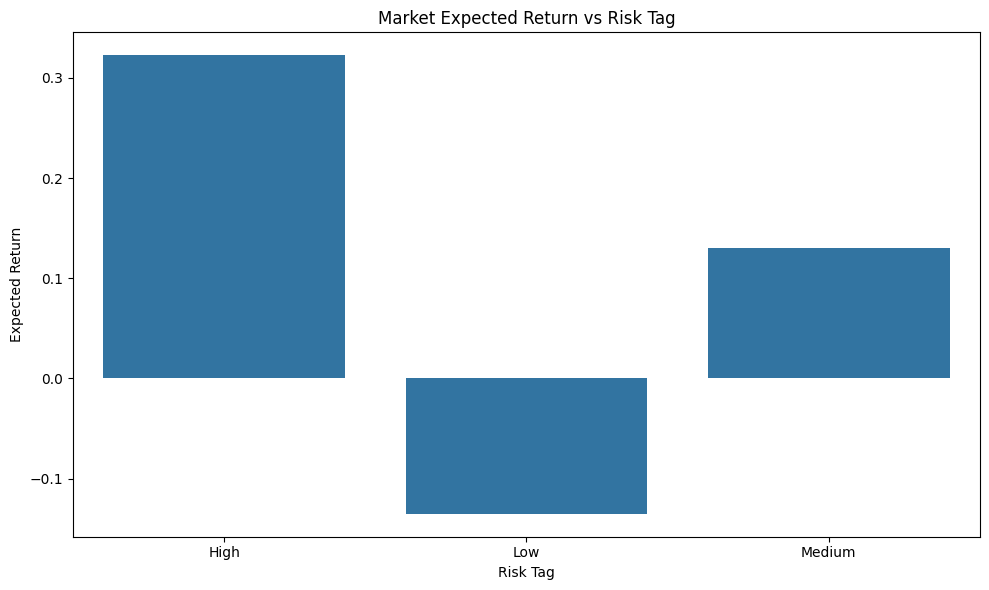

In [47]:
market_plot = (forecast_df.groupby("risk_tag")["expected_return_pct"].mean().reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=market_plot,x="risk_tag",y="expected_return_pct")
plt.title("Market Expected Return vs Risk Tag")
plt.xlabel("Risk Tag")
plt.ylabel("Expected Return")
plt.tight_layout()
plt.show()

**Insight:**

- Comparison of expected market returns across risk tags shows how potential investment returns vary with different levels of market risk.
- Companies associated with higher expected returns may also carry greater uncertainty, highlighting the fundamental trade-off between potential reward and investment risk.
- The visualization helps identify companies or risk groups that offer relatively attractive returns while maintaining comparatively manageable risk exposure.
- Combining forecasted returns with risk classifications enables investors to make more balanced investment decisions instead of evaluating expected returns in isolation.


### Phase 8: NLP Financial Sentiment

##### Step 1: Load & Clean News Headlines

In [50]:
import re
news = news_sentiment.copy()
news["clean_headline"] = news["headline"].str.lower().apply(lambda t: re.sub(r"[^a-z\s]", " ", t))
news.head(3)

,headline,company,sentiment_label,clean_headline
0,ALPHA stock surges after strong earnings beat,ALPHA,Positive,alpha stock surges after strong earnings beat
1,ALPHA holds annual shareholder meeting,ALPHA,Neutral,alpha holds annual shareholder meeting
2,ALPHA holds annual shareholder meeting,ALPHA,Neutral,alpha holds annual shareholder meeting


##### Step 2: TF-IDF Text Feature Engineering & Train Sentiment Classification Model

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(news["clean_headline"], news["sentiment_label"], test_size=0.25, 
                                                                    random_state=42, stratify=news["sentiment_label"])

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train_txt)
X_test_vec = vectorizer.transform(X_test_txt)

sentiment_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
sentiment_clf.fit(X_train_vec, y_train_txt)
print("Sentiment model trained")

Sentiment model trained


##### Step 3: Headline Sentiment Scoring & Company-Level Sentiment Insights

In [52]:
from sklearn.metrics import accuracy_score
preds = sentiment_clf.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test_txt, preds)*100:.1f}%")

all_vec = vectorizer.transform(news["clean_headline"])
proba = sentiment_clf.predict_proba(all_vec)
classes = list(sentiment_clf.classes_)
news["impact_score"] = proba[:, classes.index("Positive")] - proba[:, classes.index("Negative")]

company_impact = news.groupby("company")["impact_score"].mean().round(3).reset_index()
company_impact.to_csv("outputs/company_sentiment_impact.csv", index=False)
company_impact

Accuracy: 100.0%


,company,impact_score
0,ALPHA,0.086
1,BRAVO,0.047
2,CIVIC,0.015
3,DELTA,0.161
4,ECHO,0.069
5,FOXTEL,0.021
6,GRANITE,-0.003
7,HORIZON,0.116
8,INDUS,0.182
9,JOVIAN,0.069


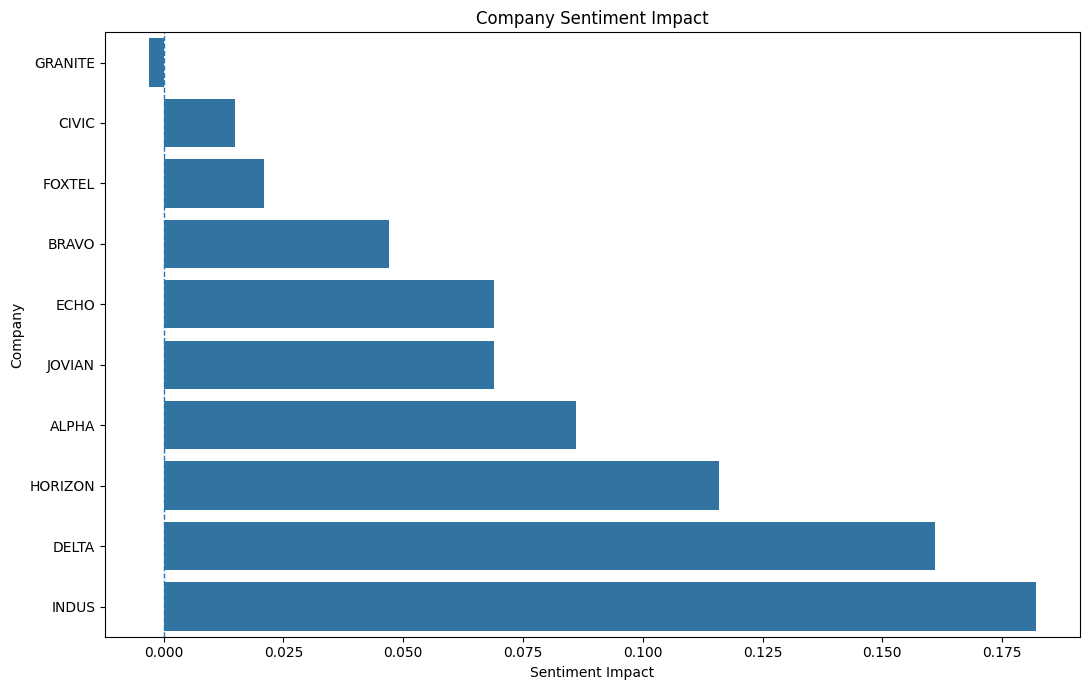

In [58]:
sentiment_plot = (company_impact.sort_values("impact_score"))

plt.figure(figsize=(11, 7))
sns.barplot(data=sentiment_plot,x="impact_score",y="company")
plt.axvline(0,linestyle="--",linewidth=1)
plt.title("Company Sentiment Impact")
plt.xlabel("Sentiment Impact")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

**Insight:**

- Company sentiment analysis highlights differences in the potential impact of positive and negative news across the companies included in the FinShield market dataset.
- Companies with strongly positive sentiment impact may benefit from favorable market perception, while companies with negative sentiment may face increased reputational and investment risk.
- The concentration of negative sentiment around specific companies provides an early-warning signal for businesses that require closer monitoring of news and market perception.
- Combining sentiment signals with market forecasts and financial risk measures creates a more comprehensive view of investment risk and potential market opportunities.


In [54]:
joblib.dump(sentiment_clf, "Models/sentiment_classifier.pkl")
joblib.dump(vectorizer, "Models/sentiment_vectorizer.pkl")
print("Saved")

Saved


In [30]:
print("""
==============================================================
 Part 2: Machine Learning Engine Completed Successfully
==============================================================
✔ Risk Classification models trained (baseline + advanced)
✔ Fraud / Anomaly Detection model trained
✔ Market Forecasting models trained
✔ NLP Sentiment model trained
✔ Model evaluation metrics generated
✔ All models serialized and saved

🚀 Next Notebook:
Part 3: Intelligence, Scoring & Explainability
The next phase will cover:
• Financial Intelligence Engine (FinShield Score)
• Explainable AI (SHAP)
• Risk Monitoring & Segmentation
• AI Recommendation Engine
==============================================================""")


 Part 2: Machine Learning Engine Completed Successfully
✔ Risk Classification models trained (baseline + advanced)
✔ Fraud / Anomaly Detection model trained
✔ Market Forecasting models trained
✔ NLP Sentiment model trained
✔ Model evaluation metrics generated
✔ All models serialized and saved

🚀 Next Notebook:
Part 3: Intelligence, Scoring & Explainability
The next phase will cover:
• Financial Intelligence Engine (FinShield Score)
• Explainable AI (SHAP)
• Risk Monitoring & Segmentation
• AI Recommendation Engine
